In [0]:
!pip install "langchain-openai==0.1.25" "langchain-core==0.2.43" "langchain==0.2.17" langgraph pygame python-dotenv langsmith
dbutils.library.restartPython()

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import os,sys
import mlflow
import subprocess
from typing import Callable
from dataclasses import dataclass
from typing import TypedDict, Annotated, List
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import BaseMessage, AIMessage, HumanMessage
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import display,Image
from dotenv import load_dotenv

In [0]:
llm = ChatOpenAI(
    base_url=f"https://{mlflow.utils.databricks_utils.get_browser_hostname()}/serving-endpoints",
    api_key=dbutils.notebook.entry_point.getDbutils().notebook().getContext().apiToken().get(),
    model="databricks-meta-llama-3-3-70b-instruct",
)
#im using this for langsmith tracing
load_dotenv()

True

##Initializing System Memory and State Management 

In [0]:
class GameState(TypedDict):
    director_messages:Annotated[list[BaseMessage],add_messages]
    architect_messages:Annotated[list[BaseMessage],add_messages]
    engineer_code: Annotated[list[BaseMessage],add_messages]
    qa_feedback: Annotated[list[BaseMessage],add_messages]
    run_output:Annotated[List[BaseMessage], add_messages]
    current_actor:str
    iteration:int
    iteration_score:list[float]
    file_saved:bool


    


## Agent Nodes

### Director and Architect Nodes

In [0]:
def director_node(state: GameState):
    '''This is the director node that takes in the '''
    # director_msg = input("Awaiting Director Prompt: ")
    director_msg="Build a Chrome Dino Runner game using pygame with cacti and pterodactyl obstacles, jumping and ducking mechanics, and a high score tracker."
    return {"director_messages": [HumanMessage(content=director_msg)],
            "current_actor":"architect",
            "iteration":0}


def architect_node(state: GameState):
    '''This is the architecht node that plans the architechture as per the requirement of the director'''

    print(f"\n========== ITERATION {state.get('iteration', 0)} ==========")
    # sys.stdout.flush()
    director_prompt=state['director_messages'][-1].content
    prompt= ChatPromptTemplate.from_template("You are a senior game architect.\
    The director has given you this request: {director_prompt}\
        \
    Break this into a detailed technical design document covering:\
    1. Game loop structure\
    2. Classes and components needed\
    3. Controls and physics\
    4. Obstacles and scoring\
    5. Required pygame features)")
    response=llm.invoke(prompt.format_messages(director_prompt=director_prompt))

    return {
        "architect_messages": [response],
        "current_actor": "engineer",
    }


###  Engineer Node

In [0]:
def engineer_node(state: GameState):
    architect_message = state["architect_messages"][-1].content
    prev_code = state["engineer_code"][-1].content if state.get("engineer_code") else "None"
    qa_messages = state["qa_feedback"][-1].content if state.get("qa_feedback") else "None"

    response = llm.invoke([HumanMessage(content=f"""You are an expert Python game developer using pygame.

ARCHITECT DESIGN:
{architect_message}

PREVIOUS CODE (if any):
{prev_code}

QA FEEDBACK TO FIX :
{qa_messages}

Write complete, runnable Python pygame code for a Dino Runner game.
Return ONLY the raw Python code. No markdown, no backticks, no explanation. SEE THE PREVIOUS QA FEEDBACK ON THE PREVIOUS CODE AND RETURN THE IMPROVED CODE. THE ARCHITECHTURE AND QA'S RESPONSE BOTH MATTER EQUALLY. THE ARCHITECHTURE CAN BE CAHNEGD TO IMPROVE THE GAMEPLAY BASED ON THE QA FEEDBACK""")])

    # # Strip markdown backticks if LLM returns them anyway
    code = response.content.strip()
    if code.startswith("```"):
        code = code.split("\n", 1)[1]  # remove first line (```python)
    if code.endswith("```"):
        code = code.rsplit("```", 1)[0]  # remove last ```
    code = code.strip()

    return {
        "engineer_code": [AIMessage(content=code)],
        "current_actor": "file_writer",
    }

### File I/O and Execution Nodes

In [0]:
def file_writer(state: GameState):
    '''This is the node that writes the python code to the file'''
    code = state["engineer_code"][-1].content

    with open("dino_runner.py", "w", encoding="utf-8") as f:
        f.write(code)

    print(code[:500])
    # sys.stdout.flush()
    print("\n[File saved: dino_runner.py]")
    # sys.stdout.flush()
    return {
        "file_saved": True,
        "current_actor": "run_code",
    }


def run_code(state: GameState):
    '''This is the node that runs the code if the User Asks it to.'''
    print("\n===== CODE EXECUTION =====")
    # sys.stdout.flush()
    choice = input("Run the generated game? (y/n): ").strip().lower()

    if choice == "y":
        try:
            result = subprocess.run(
            ["python", "dino_runner.py"],
            capture_output=True, text=True, timeout=30
            )
            output = result.stdout + result.stderr
        except subprocess.TimeoutExpired:
            output = "Game executed successfully."
        print(output[:1000])
        # sys.stdout.flush()
    else:
        output = "User skipped execution."

    return {
        "run_output": [HumanMessage(content=f"EXECUTION OUTPUT:\n{output}")],
        "current_actor": "qa",
    }

### QA and Scorer Nodes

In [0]:
def qa_node(state: GameState):
    run_output = state["run_output"][-1].content
    design_requirements = state["architect_messages"][-1].content
    engineer_code = state["engineer_code"][-1].content

    response = llm.invoke([HumanMessage(content=f"""You are a QA engineer reviewing a pygame Dino Runner game.

ORIGINAL DESIGN REQUIREMENTS:
{design_requirements}

GENERATED CODE:
{engineer_code}

EXECUTION OUTPUT:
{run_output}

List every bug, missing feature, and runtime error you can identify.
Be specific — tell the engineer exactly what to fix.""")])
    print(f"\n[QA REPORT]\n{response.content}")

    return {
        "qa_feedback": [response],
        "current_actor": "scorer",
    }


def score_node(state: GameState):
    qa_feedback = state["qa_feedback"][-1].content

    response = llm.invoke([HumanMessage(content=f"""Based on this QA report, give a single integer score from 1 to 10.
10 = fully working game, no bugs. 1 = completely broken.
Reply with ONLY the number, nothing else.

QA REPORT:
{qa_feedback}""")])

    try:
        score = float(response.content.strip())
    except ValueError:
        score = 5.0

    scores = state.get("iteration_score", [])
    scores.append(score)
    # sys.stdout.flush()
    print(f"\n[Score this iteration: {score}]")
    # sys.stdout.flush()

    return {
        "iteration_score": scores,
        "iteration": state.get("iteration", 0) + 1,
        "current_actor": "should_continue",
    }



In [0]:

def should_continue(state: GameState):
    score = state["iteration_score"][-1]
    print(f"Current score: {score}/10\n")
    choice = input("Continue iterating? (y/n): ").strip().lower()

    if choice == "y" and score < 10:
        return "engineer"
    return END

##  Graph Structure 

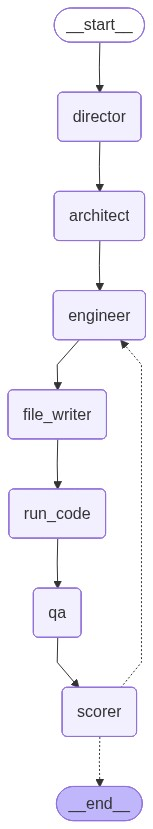

In [0]:
memory= MemorySaver()
graph=StateGraph(GameState)
graph.add_node("director",director_node)
graph.add_node("architect",architect_node)
graph.add_node("engineer",engineer_node)
graph.add_node("file_writer",file_writer)
graph.add_node("run_code",run_code)
graph.add_node("qa",qa_node)
graph.add_node("scorer",score_node)
graph.add_edge(START,"director")
graph.add_edge("director","architect")
graph.add_edge("architect","engineer")
graph.add_edge("engineer","file_writer")
graph.add_edge("file_writer","run_code")
graph.add_edge("run_code","qa")
graph.add_edge("qa","scorer")
graph.add_conditional_edges("scorer",should_continue, {"engineer":"engineer",END:END})


app=graph.compile(checkpointer=memory)
display(Image(app.get_graph().draw_mermaid_png()))

## System Invocation [10 marks]

In [0]:
config = {"configurable": {"thread_id": "dino-session-1"}}
print("--- STARTING WORKFLOW ---")
for event in app.stream({},config,stream_mode="updates"):
    # print(event)
    for node, value in event.items():
        print(f"\n===== {node.upper()} =====")
    #     # sys.stdout.flush()
    #     if node.upper()=="SCORER":
    #         print(value)
            # sys.stdout.flush()
# "Build a Chrome Dino Runner game using pygame with cacti and pterodactyl obstacles, jumping and ducking mechanics, and a high score tracker.""



--- STARTING WORKFLOW ---

===== DIRECTOR =====

========== ITERATION 0 ==========

===== ARCHITECT =====

===== ENGINEER =====
import pygame
import sys
import random

class Player:
    def __init__(self):
        self.x = 100
        self.y = 400
        self.width = 50
        self.height = 50
        self.velocity = 0
        self.gravity = 1
        self.jump_height = -20
        self.ducking = False

    def jump(self):
        if not self.ducking:
            self.velocity = self.jump_height

    def duck(self):
        self.ducking = True
        self.height = 20

    def update(self):
        self.velocity += sel

[File saved: dino_runner.py]

===== FILE_WRITER =====

===== CODE EXECUTION =====


Run the generated game? (y/n):  y

Game executed successfully.

===== RUN_CODE =====

[QA REPORT]
After reviewing the provided code, I have identified the following bugs, missing features, and potential runtime errors:

**Bugs:**

1. **Collision detection issue:** The collision detection between the player and the obstacle is not accurate. The player can sometimes pass through the obstacle or get stuck in it. To fix this, modify the collision detection code to use a more precise method, such as using the `pygame.Rect` class to check for collisions.
2. **Jumping issue:** The player's jumping mechanic is not smooth. The player can jump multiple times in a row without touching the ground. To fix this, add a check to ensure that the player can only jump when they are on the ground.
3. **Ducking issue:** The player's ducking mechanic is not smooth. The player can duck and jump at the same time, which can cause the player to get stuck in the ducking position. To fix this, add a check to ensure that the player can only duck wh

Continue iterating? (y/n):  y


===== SCORER =====

===== ENGINEER =====
import pygame
import sys
import random
import json

# Constants
WIDTH, HEIGHT = 700, 500
PLAYER_SIZE = 50
OBSTACLE_SIZE = 50
GRAVITY = 1
JUMP_HEIGHT = -20
DUCK_HEIGHT = 20
OBSTACLE_SPAWN_RATE = 100
HIGH_SCORE_FILE = 'high_score.json'

class Player:
    def __init__(self):
        self.x = 100
        self.y = HEIGHT - PLAYER_SIZE
        self.width = PLAYER_SIZE
        self.height = PLAYER_SIZE
        self.velocity = 0
        self.gravity = GRAVITY
        self.jump_height = JUMP_HEIGHT
     

[File saved: dino_runner.py]

===== FILE_WRITER =====

===== CODE EXECUTION =====


...


===== SCORER =====

===== ENGINEER =====
import pygame
import sys
import random
import json

# Constants
WIDTH, HEIGHT = 700, 500
PLAYER_SIZE = 50
OBSTACLE_SIZE = 50
GRAVITY = 1
JUMP_HEIGHT = -20
DUCK_HEIGHT = 20
OBSTACLE_SPAWN_RATE = 100
HIGH_SCORE_FILE = 'high_score.json'

class Player:
    def __init__(self):
        self.x = 100
        self.y = HEIGHT - PLAYER_SIZE
        self.width = PLAYER_SIZE
        self.height = PLAYER_SIZE
        self.velocity = 0
        self.gravity = GRAVITY
        self.jump_height = JUMP_HEIGHT
     

[File saved: dino_runner.py]

===== FILE_WRITER =====

===== CODE EXECUTION =====


Run the generated game? (y/n):  n


===== RUN_CODE =====

[QA REPORT]
# Step-by-step analysis of the problem:
1. **The player's ducking state is not being reset properly**: When the player is ducking and the down arrow key is released, the player's height is not being reset to the original height. To fix this, the `unduck` method should be called when the down arrow key is released.
2. **The game does not handle the case where the player collides with multiple obstacles at the same time**: If the player collides with multiple obstacles at the same time, the game will only remove the first obstacle from the list and will not check for collisions with the remaining obstacles. To fix this, the game should check for collisions with all obstacles in the list, not just the first one.
3. **The game does not have a way to quit the game without using the 'q' key**: The game should have a way to quit the game without using the 'q' key, such as by closing the window. To fix this, the game should handle the `QUIT` event properly.
4

Continue iterating? (y/n):  n


===== SCORER =====
